# 04 Expert: LLM Analysis, DSS Export & Configuration

This notebook covers py2dataiku's advanced capabilities:

1. **LLM-based conversion** using `convert_with_llm()` and `MockProvider`
2. **LLM providers** -- factory pattern and provider classes
3. **LLMCodeAnalyzer** -- direct analysis with `AnalysisResult`
4. **OperationType enum** and `DataStep` internals
5. **Rule-based vs LLM-based** comparison
6. **Py2Dataiku hybrid class** with automatic fallback
7. **Configuration** via `Py2DataikuConfig` and config files
8. **DSS Export** with `DSSExporter` and `export_to_dss()`
9. **Dataset connections** and `ColumnSchema`
10. **Flow zones** for organizing large flows

## 1. LLM-Based Conversion with MockProvider

py2dataiku's recommended analysis mode uses an LLM to understand code semantics.
For demos and testing, `MockProvider` lets us work without any API key.

In [1]:
import json
from py2dataiku import convert_with_llm, convert, MockProvider, get_provider

In [2]:
# MockProvider returns a default JSON response for any prompt.
# This lets us exercise the full LLM pipeline without an API key.
mock = MockProvider()

# Call complete() to see the default mock response
response = mock.complete("Analyze this code")
print("Model:", response.model)
print("Content:", response.content)

Model: mock
Content: {"steps": [], "datasets": [], "code_summary": "Mock analysis"}


In [3]:
# MockProvider can also be initialized with custom responses.
# Keys are matched as substrings against the prompt.
custom_mock = MockProvider(responses={
    "read_csv": json.dumps({
        "code_summary": "Reads a CSV file and drops missing values",
        "total_operations": 2,
        "complexity_score": 2,
        "datasets": [
            {"name": "raw_data", "source": "data.csv", "is_input": True, "is_output": False, "inferred_columns": ["id", "name", "value"]},
            {"name": "clean_data", "source": "derived", "is_input": False, "is_output": True, "inferred_columns": ["id", "name", "value"]}
        ],
        "steps": [
            {
                "step_number": 1,
                "operation": "read_data",
                "description": "Read CSV file into DataFrame",
                "input_datasets": [],
                "output_dataset": "raw_data",
                "columns": ["id", "name", "value"],
                "suggested_recipe": "sync",
                "requires_python_recipe": False
            },
            {
                "step_number": 2,
                "operation": "drop_missing",
                "description": "Drop rows with missing values",
                "input_datasets": ["raw_data"],
                "output_dataset": "clean_data",
                "columns": [],
                "suggested_recipe": "prepare",
                "suggested_processors": ["RemoveRowsOnEmpty"],
                "requires_python_recipe": False
            }
        ],
        "recommendations": ["Consider adding data validation before dropping rows"],
        "warnings": []
    })
})

# complete_json() parses the response as JSON automatically
result = custom_mock.complete_json("Analyze: df = pd.read_csv('data.csv')")
print("Summary:", result["code_summary"])
print("Steps:", result["total_operations"])

Summary: Reads a CSV file and drops missing values
Steps: 2


In [4]:
# MockProvider tracks all calls made to it (useful for testing)
print(f"Calls made to custom_mock: {len(custom_mock.calls)}")
print(f"Last prompt contained: ...{custom_mock.calls[-1]['prompt'][:50]}...")

Calls made to custom_mock: 1
Last prompt contained: ...Analyze: df = pd.read_csv('data.csv')...


## 2. LLM Provider Architecture

py2dataiku supports multiple LLM providers via a common `LLMProvider` ABC:

- **AnthropicProvider** -- Claude models (default: claude-sonnet-4-20250514)
- **OpenAIProvider** -- GPT models (default: gpt-4o)
- **MockProvider** -- Testing without API calls

The `get_provider()` factory creates the right provider by name.

In [5]:
from py2dataiku import AnthropicProvider, OpenAIProvider, MockProvider, get_provider
from py2dataiku.llm.providers import LLMProvider, LLMResponse

# get_provider() is the factory function
mock_provider = get_provider("mock")
print(f"Provider type: {type(mock_provider).__name__}")
print(f"Model name: {mock_provider.model_name}")

Provider type: MockProvider
Model name: mock


In [6]:
# LLMProvider defines the interface: complete(), complete_json(), model_name
# All providers return LLMResponse objects
resp = mock_provider.complete("Hello")
print(f"Response type: {type(resp).__name__}")
print(f"Fields: content={resp.content!r}, model={resp.model!r}, usage={resp.usage}")

Response type: LLMResponse
Fields: content='{"steps": [], "datasets": [], "code_summary": "Mock analysis"}', model='mock', usage=None


In [7]:
# AnthropicProvider and OpenAIProvider require API keys.
# They will raise ValueError if no key is found:
try:
    get_provider("anthropic", api_key=None)
except ValueError as e:
    print(f"Expected error: {e}")

try:
    get_provider("openai", api_key=None)
except ValueError as e:
    print(f"Expected error: {e}")

# Unknown providers also raise ValueError
try:
    get_provider("unknown_provider")
except ValueError as e:
    print(f"Expected error: {e}")

Expected error: Anthropic API key required. Set ANTHROPIC_API_KEY environment variable or pass api_key parameter. (Or use the rule-based convert() instead.)
Expected error: OpenAI API key required. Set OPENAI_API_KEY environment variable or pass api_key parameter. (Or use the rule-based convert() instead.)
Expected error: Unknown provider: unknown_provider


## 3. LLMCodeAnalyzer and AnalysisResult

`LLMCodeAnalyzer` is the core class that sends code to an LLM and parses the
structured response into an `AnalysisResult`.

In [8]:
from py2dataiku import LLMCodeAnalyzer, AnalysisResult, DataStep, OperationType
from py2dataiku.llm.schemas import DatasetInfo

# Create an analyzer with a custom MockProvider that returns a rich response
mock_response = json.dumps({
    "code_summary": "ETL pipeline that reads sales data, cleans it, joins with products, and aggregates by category",
    "total_operations": 5,
    "complexity_score": 6,
    "datasets": [
        {"name": "sales", "source": "sales.csv", "is_input": True, "is_output": False, "inferred_columns": ["order_id", "product_id", "amount", "date"]},
        {"name": "products", "source": "products.csv", "is_input": True, "is_output": False, "inferred_columns": ["product_id", "name", "category"]},
        {"name": "sales_clean", "source": "derived", "is_input": False, "is_output": False, "inferred_columns": ["order_id", "product_id", "amount", "date"]},
        {"name": "sales_with_products", "source": "derived", "is_input": False, "is_output": False, "inferred_columns": ["order_id", "product_id", "amount", "date", "name", "category"]},
        {"name": "category_totals", "source": "derived", "is_input": False, "is_output": True, "inferred_columns": ["category", "total_amount", "order_count"]}
    ],
    "steps": [
        {
            "step_number": 1,
            "operation": "read_data",
            "description": "Read sales CSV file",
            "input_datasets": [],
            "output_dataset": "sales",
            "columns": ["order_id", "product_id", "amount", "date"],
            "suggested_recipe": "sync",
            "requires_python_recipe": False,
            "reasoning": "Simple file read maps to sync recipe"
        },
        {
            "step_number": 2,
            "operation": "read_data",
            "description": "Read products CSV file",
            "input_datasets": [],
            "output_dataset": "products",
            "columns": ["product_id", "name", "category"],
            "suggested_recipe": "sync",
            "requires_python_recipe": False,
            "reasoning": "Simple file read maps to sync recipe"
        },
        {
            "step_number": 3,
            "operation": "drop_missing",
            "description": "Remove rows with null amounts",
            "input_datasets": ["sales"],
            "output_dataset": "sales_clean",
            "columns": ["amount"],
            "suggested_recipe": "prepare",
            "suggested_processors": ["RemoveRowsOnEmpty"],
            "requires_python_recipe": False,
            "reasoning": "dropna maps to RemoveRowsOnEmpty processor in prepare recipe"
        },
        {
            "step_number": 4,
            "operation": "join",
            "description": "Join sales with products on product_id",
            "input_datasets": ["sales_clean", "products"],
            "output_dataset": "sales_with_products",
            "columns": ["product_id"],
            "join_conditions": [{"left_column": "product_id", "right_column": "product_id", "operator": "equals"}],
            "join_type": "left",
            "suggested_recipe": "join",
            "requires_python_recipe": False,
            "reasoning": "pd.merge with on='product_id' maps to join recipe"
        },
        {
            "step_number": 5,
            "operation": "group_aggregate",
            "description": "Aggregate sales by category",
            "input_datasets": ["sales_with_products"],
            "output_dataset": "category_totals",
            "columns": ["category", "amount"],
            "group_by_columns": ["category"],
            "aggregations": [
                {"column": "amount", "function": "sum", "output_column": "total_amount"},
                {"column": "order_id", "function": "count", "output_column": "order_count"}
            ],
            "suggested_recipe": "grouping",
            "requires_python_recipe": False,
            "reasoning": "groupby().agg() maps to grouping recipe"
        }
    ],
    "recommendations": [
        "Consider filtering before join to reduce data volume",
        "Add data quality checks on the amount column"
    ],
    "warnings": ["Date column not parsed -- consider adding date parsing step"]
})

# Create analyzer with the custom mock
mock_for_analysis = MockProvider(responses={"Analyze": mock_response})
analyzer = LLMCodeAnalyzer(provider=mock_for_analysis)
print(f"Analyzer provider: {analyzer.provider.model_name}")

Analyzer provider: mock


In [9]:
# Analyze code -- the LLM (mock) extracts data manipulation steps
code = """
import pandas as pd
sales = pd.read_csv('sales.csv')
products = pd.read_csv('products.csv')
sales_clean = sales.dropna(subset=['amount'])
merged = sales_clean.merge(products, on='product_id', how='left')
result = merged.groupby('category').agg(
    total_amount=('amount', 'sum'),
    order_count=('order_id', 'count')
)
"""

analysis = analyzer.analyze(code)
print(f"Type: {type(analysis).__name__}")
print(f"Code summary: {analysis.code_summary}")
print(f"Complexity score: {analysis.complexity_score}/10")
print(f"Total operations: {analysis.total_operations}")
print(f"Model used: {analysis.model_used}")

Type: AnalysisResult
Code summary: ETL pipeline that reads sales data, cleans it, joins with products, and aggregates by category
Complexity score: 6/10
Total operations: 5
Model used: mock


In [10]:
# Examine datasets identified by the LLM
print(f"Datasets found: {len(analysis.datasets)}")
for ds in analysis.datasets:
    role = "INPUT" if ds.is_input else ("OUTPUT" if ds.is_output else "INTERMEDIATE")
    print(f"  {ds.name}: {role} (source={ds.source}, columns={ds.inferred_columns})")

Datasets found: 5
  sales: INPUT (source=sales.csv, columns=['order_id', 'product_id', 'amount', 'date'])
  products: INPUT (source=products.csv, columns=['product_id', 'name', 'category'])
  sales_clean: INTERMEDIATE (source=derived, columns=['order_id', 'product_id', 'amount', 'date'])
  sales_with_products: INTERMEDIATE (source=derived, columns=['order_id', 'product_id', 'amount', 'date', 'name', 'category'])
  category_totals: OUTPUT (source=derived, columns=['category', 'total_amount', 'order_count'])


In [11]:
# Examine each analysis step
print(f"Steps: {len(analysis.steps)}\n")
for step in analysis.steps:
    print(f"Step {step.step_number}: {step.description}")
    print(f"  Operation: {step.operation.value}")
    print(f"  Inputs: {step.input_datasets} -> Output: {step.output_dataset}")
    print(f"  Suggested recipe: {step.suggested_recipe}")
    if step.suggested_processors:
        print(f"  Suggested processors: {step.suggested_processors}")
    if step.reasoning:
        print(f"  Reasoning: {step.reasoning}")
    print()

Steps: 5

Step 1: Read sales CSV file
  Operation: read_data
  Inputs: [] -> Output: sales
  Suggested recipe: sync
  Reasoning: Simple file read maps to sync recipe

Step 2: Read products CSV file
  Operation: read_data
  Inputs: [] -> Output: products
  Suggested recipe: sync
  Reasoning: Simple file read maps to sync recipe

Step 3: Remove rows with null amounts
  Operation: drop_missing
  Inputs: ['sales'] -> Output: sales_clean
  Suggested recipe: prepare
  Suggested processors: ['RemoveRowsOnEmpty']
  Reasoning: dropna maps to RemoveRowsOnEmpty processor in prepare recipe

Step 4: Join sales with products on product_id
  Operation: join
  Inputs: ['sales_clean', 'products'] -> Output: sales_with_products
  Suggested recipe: join
  Reasoning: pd.merge with on='product_id' maps to join recipe

Step 5: Aggregate sales by category
  Operation: group_aggregate
  Inputs: ['sales_with_products'] -> Output: category_totals
  Suggested recipe: grouping
  Reasoning: groupby().agg() maps to

In [12]:
# AnalysisResult also includes recommendations and warnings
print("Recommendations:")
for rec in analysis.recommendations:
    print(f"  - {rec}")

print("\nWarnings:")
for warn in analysis.warnings:
    print(f"  - {warn}")

Recommendations:
  - Consider filtering before join to reduce data volume
  - Add data quality checks on the amount column

Warnings:
  - Date column not parsed -- consider adding date parsing step


In [13]:
# AnalysisResult supports serialization
analysis_dict = analysis.to_dict()
print("Keys:", list(analysis_dict.keys()))

# Convert to JSON string
analysis_json = analysis.to_json(indent=2)
print(f"\nJSON length: {len(analysis_json)} chars")
print(analysis_json[:200], "...")

Keys: ['steps', 'datasets', 'code_summary', 'total_operations', 'complexity_score', 'recommendations', 'warnings', 'model_used', 'usage']

JSON length: 5877 chars
{
  "steps": [
    {
      "step_number": 1,
      "operation": "read_data",
      "description": "Read sales CSV file",
      "input_datasets": [],
      "output_dataset": "sales",
      "columns": [ ...


In [14]:
# Round-trip: reconstruct from dict
restored = AnalysisResult.from_dict(analysis_dict)
print(f"Restored summary: {restored.code_summary}")
print(f"Restored steps: {len(restored.steps)}")
print(f"Restored complexity: {restored.complexity_score}")

Restored summary: ETL pipeline that reads sales data, cleans it, joins with products, and aggregates by category
Restored steps: 5
Restored complexity: 6


## 4. OperationType Enum and DataStep Details

`OperationType` defines all 28 operation types the LLM can detect.
`DataStep` holds the full details for each operation.

In [15]:
from py2dataiku import OperationType

# List all operation types grouped by category
categories = {
    "Data I/O": [OperationType.READ_DATA, OperationType.WRITE_DATA],
    "Transformations": [
        OperationType.FILTER, OperationType.SELECT_COLUMNS,
        OperationType.DROP_COLUMNS, OperationType.RENAME_COLUMNS,
        OperationType.ADD_COLUMN, OperationType.TRANSFORM_COLUMN,
    ],
    "Missing Values": [OperationType.FILL_MISSING, OperationType.DROP_MISSING],
    "Deduplication": [OperationType.DROP_DUPLICATES],
    "Aggregation": [OperationType.GROUP_AGGREGATE, OperationType.WINDOW_FUNCTION],
    "Combining": [OperationType.JOIN, OperationType.UNION],
    "Reshaping": [OperationType.PIVOT, OperationType.UNPIVOT],
    "Sorting": [OperationType.SORT, OperationType.TOP_N, OperationType.SAMPLE],
    "Type Conversion": [OperationType.CAST_TYPE, OperationType.PARSE_DATE],
    "Column Ops": [OperationType.SPLIT_COLUMN, OperationType.ENCODE_CATEGORICAL],
    "Scaling": [OperationType.NORMALIZE_SCALE],
    "Geographic": [OperationType.GEO_OPERATION],
    "Custom": [OperationType.CUSTOM_FUNCTION, OperationType.UNKNOWN],
}

total = 0
for cat, ops in categories.items():
    print(f"{cat}:")
    for op in ops:
        print(f"  {op.value}")
        total += 1
print(f"\nTotal: {total} operation types")

Data I/O:
  read_data
  write_data
Transformations:
  filter
  select_columns
  drop_columns
  rename_columns
  add_column
  transform_column
Missing Values:
  fill_missing
  drop_missing
Deduplication:
  drop_duplicates
Aggregation:
  group_aggregate
  window_function
Combining:
  join
  union
Reshaping:
  pivot
  unpivot
Sorting:
  sort
  top_n
  sample
Type Conversion:
  cast_type
  parse_date
Column Ops:
  split_column
  encode_categorical
Scaling:
  normalize_scale
Geographic:
  geo_operation
Custom:
  custom_function
  unknown

Total: 28 operation types


In [16]:
# DataStep holds operation-specific details.
# Let's examine the join step from our analysis.
join_step = analysis.steps[3]  # Step 4: join
print(f"Operation: {join_step.operation.value}")
print(f"Join type: {join_step.join_type}")
print(f"Join conditions:")
for jc in join_step.join_conditions:
    print(f"  {jc.left_column} {jc.operator} {jc.right_column}")

# And the aggregation step
agg_step = analysis.steps[4]  # Step 5: group_aggregate
print(f"\nGroup by: {agg_step.group_by_columns}")
print(f"Aggregations:")
for agg in agg_step.aggregations:
    print(f"  {agg.function}({agg.column}) -> {agg.output_column}")

Operation: join
Join type: left
Join conditions:
  product_id equals product_id

Group by: ['category']
Aggregations:
  sum(amount) -> total_amount
  count(order_id) -> order_count


In [17]:
# DataStep.to_dict() for serialization
step_dict = join_step.to_dict()
print(json.dumps(step_dict, indent=2))

{
  "step_number": 4,
  "operation": "join",
  "description": "Join sales with products on product_id",
  "input_datasets": [
    "sales_clean",
    "products"
  ],
  "output_dataset": "sales_with_products",
  "columns": [
    "product_id"
  ],
  "filter_conditions": [],
  "aggregations": [],
  "group_by_columns": [],
  "join_conditions": [
    {
      "left": "product_id",
      "right": "product_id",
      "operator": "equals"
    }
  ],
  "join_type": "left",
  "column_transforms": [],
  "rename_mapping": {},
  "sort_columns": [],
  "fill_value": null,
  "source_lines": [],
  "suggested_recipe": "join",
  "suggested_processors": [],
  "requires_python_recipe": false,
  "reasoning": "pd.merge with on='product_id' maps to join recipe",
  "confidence": null
}


## 5. Optimization Suggestions from LLMCodeAnalyzer

The analyzer can provide optimization suggestions based on the analysis result.

In [18]:
# get_optimization_suggestions examines the analysis for improvement opportunities
suggestions = analyzer.get_optimization_suggestions(analysis)
print(f"Optimization suggestions: {len(suggestions)}")
for s in suggestions:
    print(f"  - {s}")

Optimization suggestions: 0


## 6. Rule-Based vs LLM-Based Comparison

py2dataiku offers two analysis modes. Let's compare them on the same code.

In [19]:
from py2dataiku import convert, LLMFlowGenerator

comparison_code = """
import pandas as pd
df = pd.read_csv('data.csv')
df = df.dropna()
df = df.rename(columns={'old_name': 'new_name'})
result = df.groupby('category').agg({'amount': 'sum'})
result.to_csv('output.csv')
"""

# Rule-based conversion (uses AST pattern matching)
rule_flow = convert(comparison_code)
print("=== Rule-Based Flow ===")
print(f"Recipes: {len(rule_flow.recipes)}")
for r in rule_flow.recipes:
    print(f"  {r.name}: {r.recipe_type.value} ({r.inputs} -> {r.outputs})")
print(f"Datasets: {len(rule_flow.datasets)}")

=== Rule-Based Flow ===
Recipes: 2
  prepare_1: prepare (['df'] -> ['df_prepared'])
  grouping_2: grouping (['df_prepared'] -> ['result'])
Datasets: 3


In [20]:
# LLM-based conversion (using our MockProvider with a tailored response)
llm_mock_response = json.dumps({
    "code_summary": "Reads CSV, cleans, renames, aggregates by category, writes output",
    "total_operations": 5,
    "complexity_score": 4,
    "datasets": [
        {"name": "data", "source": "data.csv", "is_input": True, "is_output": False, "inferred_columns": ["old_name", "category", "amount"]},
        {"name": "data_clean", "source": "derived", "is_input": False, "is_output": False, "inferred_columns": ["old_name", "category", "amount"]},
        {"name": "data_renamed", "source": "derived", "is_input": False, "is_output": False, "inferred_columns": ["new_name", "category", "amount"]},
        {"name": "category_summary", "source": "derived", "is_input": False, "is_output": True, "inferred_columns": ["category", "amount"]}
    ],
    "steps": [
        {"step_number": 1, "operation": "read_data", "description": "Read CSV", "input_datasets": [], "output_dataset": "data", "columns": [], "suggested_recipe": "sync", "requires_python_recipe": False},
        {"step_number": 2, "operation": "drop_missing", "description": "Drop nulls", "input_datasets": ["data"], "output_dataset": "data_clean", "columns": [], "suggested_recipe": "prepare", "suggested_processors": ["RemoveRowsOnEmpty"], "requires_python_recipe": False},
        {"step_number": 3, "operation": "rename_columns", "description": "Rename old_name to new_name", "input_datasets": ["data_clean"], "output_dataset": "data_renamed", "columns": ["old_name"], "rename_mapping": {"old_name": "new_name"}, "suggested_recipe": "prepare", "suggested_processors": ["ColumnRenamer"], "requires_python_recipe": False},
        {"step_number": 4, "operation": "group_aggregate", "description": "Sum amount by category", "input_datasets": ["data_renamed"], "output_dataset": "category_summary", "columns": ["category", "amount"], "group_by_columns": ["category"], "aggregations": [{"column": "amount", "function": "sum", "output_column": "amount"}], "suggested_recipe": "grouping", "requires_python_recipe": False},
        {"step_number": 5, "operation": "write_data", "description": "Write to CSV", "input_datasets": ["category_summary"], "output_dataset": "output", "columns": [], "suggested_recipe": "sync", "requires_python_recipe": False}
    ],
    "recommendations": ["Consecutive prepare steps (drop_missing + rename) could be merged into one Prepare recipe"],
    "warnings": []
})

llm_mock = MockProvider(responses={"Analyze": llm_mock_response})
llm_analyzer = LLMCodeAnalyzer(provider=llm_mock)
llm_analysis = llm_analyzer.analyze(comparison_code)

# Generate flow from LLM analysis
llm_gen = LLMFlowGenerator()
llm_flow = llm_gen.generate(llm_analysis, flow_name="llm_pipeline")

print("=== LLM-Based Flow ===")
print(f"Recipes: {len(llm_flow.recipes)}")
for r in llm_flow.recipes:
    print(f"  {r.name}: {r.recipe_type.value} ({r.inputs} -> {r.outputs})")
print(f"Datasets: {len(llm_flow.datasets)}")

=== LLM-Based Flow ===
Recipes: 2
  prepare_1: prepare (['data'] -> ['data_renamed'])
  grouping_2: grouping (['data_renamed'] -> ['category_summary'])
Datasets: 3


In [21]:
# Key differences between the two approaches:
print("Comparison Summary:")
print(f"  Rule-based: {len(rule_flow.recipes)} recipes, {len(rule_flow.datasets)} datasets")
print(f"  LLM-based:  {len(llm_flow.recipes)} recipes, {len(llm_flow.datasets)} datasets")
print()
print("Rule-based advantages:")
print("  - Fast, deterministic, offline")
print("  - No API key needed")
print("  - Predictable output")
print()
print("LLM-based advantages:")
print("  - Understands code semantics")
print("  - Handles complex/ambiguous patterns")
print("  - Provides reasoning and recommendations")
print("  - Better accuracy for non-standard code")

Comparison Summary:
  Rule-based: 2 recipes, 3 datasets
  LLM-based:  2 recipes, 3 datasets

Rule-based advantages:
  - Fast, deterministic, offline
  - No API key needed
  - Predictable output

LLM-based advantages:
  - Understands code semantics
  - Handles complex/ambiguous patterns
  - Provides reasoning and recommendations
  - Better accuracy for non-standard code


## 7. Py2Dataiku Hybrid Class

The `Py2Dataiku` class provides a unified interface with automatic fallback:
if LLM initialization fails, it falls back to rule-based analysis.

In [22]:
from py2dataiku import Py2Dataiku

# Without a valid API key, Py2Dataiku falls back to rule-based
import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    converter = Py2Dataiku(provider="anthropic", use_llm=True)
    if w:
        print(f"Warning: {w[0].message}")
    print(f"Using LLM: {converter.use_llm}")

Using LLM: False


In [23]:
# Rule-based mode works without any API key
converter_rules = Py2Dataiku(use_llm=False)
print(f"Using LLM: {converter_rules.use_llm}")

simple_code = """
import pandas as pd
df = pd.read_csv('input.csv')
df['total'] = df['price'] * df['qty']
df.to_csv('output.csv')
"""

flow = converter_rules.convert(simple_code, flow_name="hybrid_demo")
print(f"\nFlow: {flow.name}")
print(f"Recipes: {len(flow.recipes)}")
for r in flow.recipes:
    print(f"  {r.name}: {r.recipe_type.value}")

Using LLM: False

Flow: hybrid_demo
Recipes: 0


In [24]:
# Py2Dataiku also wraps visualization methods
ascii_viz = converter_rules.visualize(flow, format="ascii")
print(ascii_viz)

════════════════════════════════════════════════════════════════════════════════
                           DATAIKU FLOW: hybrid_demo  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [OUTPUT]       │
                              └──────────────────┘

════════════════════════════════════════════════════════════════════════════════

Legend: 📊 Dataset  ⚙ Prepare  ⋈ Join  Σ Grouping  ▦ Window  ⑂ Split  ⇅ Sort  ★ Distinct  λ Python  § SQL  ⚡ Spark  ◉ ML


### PNG Export (Matplotlib)

The `MatplotlibVisualizer` produces polished PNG diagrams with DDODS-inspired styling — semantic colors, rounded nodes, and flow zone backgrounds.

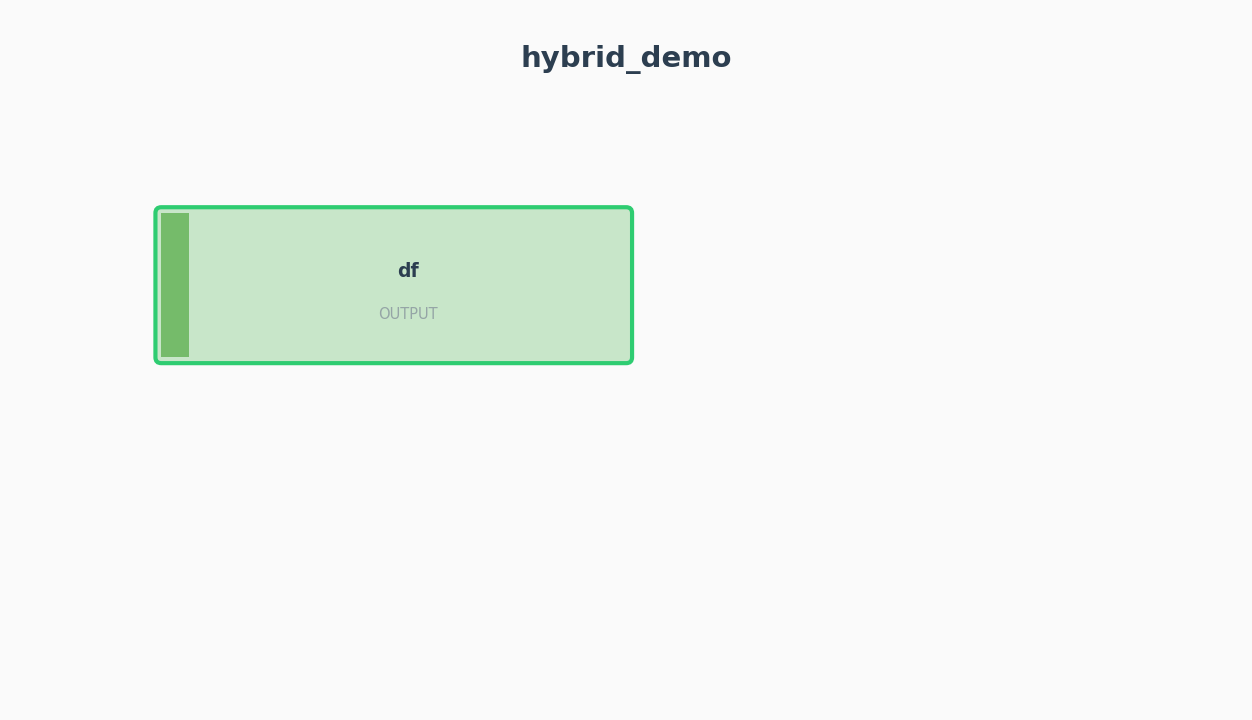

In [25]:
# PNG export - publication-quality diagram
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

viz = MatplotlibVisualizer()
png_bytes = viz.render(flow)
display(Image(png_bytes))

### Flow Zone Visualization

Assign datasets and recipes to named `FlowZone` groups. Zones appear as color-coded dashed regions in SVG and PNG diagrams, and as `subgraph` blocks in Mermaid output.

In [26]:
from py2dataiku.models.dataiku_flow import FlowZone

# Assign nodes to named zones
if flow.datasets and flow.recipes:
    dataset_names = [d.name for d in flow.datasets]
    recipe_names = [r.name for r in flow.recipes]
    
    mid_d = max(1, len(dataset_names) // 2)
    mid_r = max(1, len(recipe_names) // 2)
    
    flow.zones = [
        FlowZone(
            name="Ingestion",
            color="#E3F2FD",
            datasets=dataset_names[:mid_d],
            recipes=recipe_names[:mid_r],
        ),
        FlowZone(
            name="Analysis",
            color="#E8F5E9",
            datasets=dataset_names[mid_d:],
            recipes=recipe_names[mid_r:],
        ),
    ]
    print(f"Assigned {mid_d} datasets and {mid_r} recipes to 'Ingestion' zone")
    print(f"Assigned {len(dataset_names)-mid_d} datasets and {len(recipe_names)-mid_r} recipes to 'Analysis' zone")

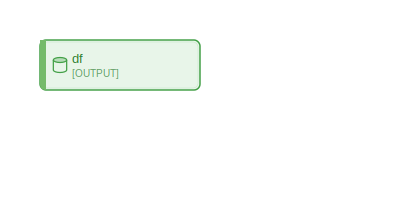

In [27]:
# SVG with zone regions (dashed borders + label badges)
from IPython.display import SVG, display
display(SVG(flow.visualize(format="svg")))

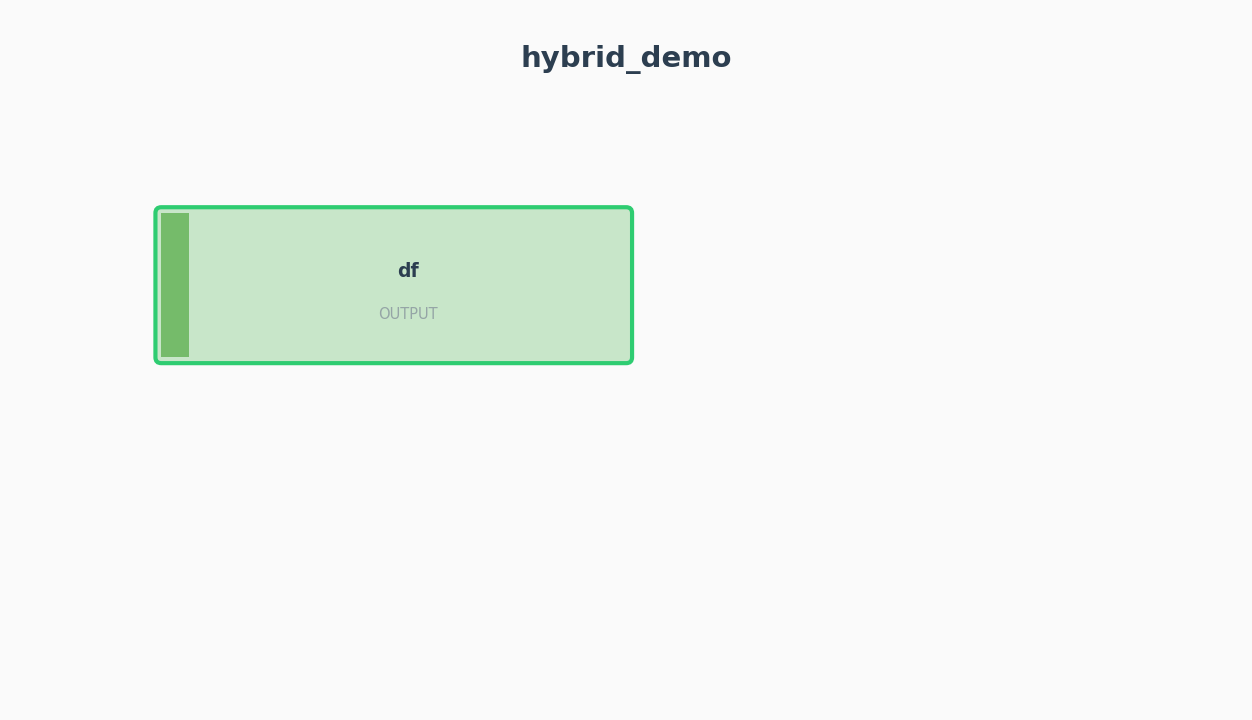

In [28]:
# PNG with zone backgrounds
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

png_bytes = MatplotlibVisualizer().render(flow)
display(Image(png_bytes))

In [29]:
# Mermaid visualization of the same flow
mermaid_viz = converter_rules.visualize(flow, format='mermaid')
print(mermaid_viz)

flowchart TD
    subgraph outputs[Output Datasets]
        D0[(df)]
    end

    style D0 fill:#c8e6c9


In [30]:
# PlantUML visualization
plantuml_viz = converter_rules.visualize(flow, format='plantuml')
print(plantuml_viz)

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles (per-type, DSS-palette)
skinparam card {
  BackgroundColor<<prepare>> #2c8fd9
  BorderColor<<prepare>> #1f6fa9
  FontColor<<prepare>> #ffffff
  BackgroundColor<<sync>> #5d6d7e
  BorderColor<<sync>> #3d4d5e
  FontColor<<sync>> #ffffff
  BackgroundColor<<grouping>> #75bb6a
  BorderColor<<grouping>> #5a9151
  FontColor<<grouping>> #ffffff
  BackgroundColor<<window>> #9b59b6
  BorderColor<<window>> #7d3f97
  FontColor<<window>> #ffffff
  BackgroundColor<<join>> #f29222
  BorderColor<<join>> #c4761a
  FontColor<<j

In [31]:
# The analyze() method is only available in LLM mode
try:
    converter_rules.analyze(simple_code)
except ValueError as e:
    print(f"Expected error: {e}")

Expected error: analyze() requires LLM mode. Initialize with use_llm=True


## 8. Configuration with Py2DataikuConfig

`Py2DataikuConfig` centralizes all settings. Configuration can come from:
- Python code (direct construction)
- TOML files (`py2dataiku.toml`)
- YAML files (`.py2dataiku.yaml` / `.py2dataiku.yml`)
- RC files (`.py2dataikurc`)
- Environment variables (`PY2DATAIKU_PROVIDER`, `PY2DATAIKU_PROJECT_KEY`)

In [32]:
from py2dataiku import Py2DataikuConfig, load_config, find_config_file

# Default configuration
config = Py2DataikuConfig()
print("Default configuration:")
print(f"  Provider: {config.default_provider}")
print(f"  Model: {config.default_model}")
print(f"  Project key: {config.project_key}")
print(f"  Flow name: {config.flow_name}")
print(f"  Optimize: {config.optimize}")
print(f"  Optimization level: {config.optimization_level}")
print(f"  Default format: {config.default_format}")
print(f"  Default connection: {config.default_connection}")

Default configuration:
  Provider: anthropic
  Model: None
  Project key: MY_PROJECT
  Flow name: converted_flow
  Optimize: True
  Optimization level: 1
  Default format: svg
  Default connection: Filesystem


In [33]:
# Custom configuration
custom_config = Py2DataikuConfig(
    default_provider="openai",
    default_model="gpt-4o",
    project_key="SALES_PIPELINE",
    flow_name="sales_etl",
    optimize=True,
    optimization_level=2,
    dataset_prefix="src_",
    dataset_suffix="_v2",
    recipe_prefix="compute_",
    default_format="html",
    default_connection="PostgreSQL",
)

print("Custom configuration:")
print(f"  Provider: {custom_config.default_provider}")
print(f"  Project key: {custom_config.project_key}")
print(f"  Dataset prefix: {custom_config.dataset_prefix!r}")
print(f"  Dataset suffix: {custom_config.dataset_suffix!r}")
print(f"  Recipe prefix: {custom_config.recipe_prefix!r}")
print(f"  Connection: {custom_config.default_connection}")

Custom configuration:
  Provider: openai
  Project key: SALES_PIPELINE
  Dataset prefix: 'src_'
  Dataset suffix: '_v2'
  Recipe prefix: 'compute_'
  Connection: PostgreSQL


In [34]:
# Config can be serialized to dict and back
config_dict = custom_config.to_dict()
print("Serialized config:")
print(json.dumps(config_dict, indent=2))

Serialized config:
{
  "provider": {
    "default": "openai",
    "model": "gpt-4o"
  },
  "project": {
    "key": "SALES_PIPELINE",
    "flow_name": "sales_etl"
  },
  "optimization": {
    "enabled": true,
    "level": 2
  },
  "naming": {
    "dataset_prefix": "src_",
    "dataset_suffix": "_v2",
    "recipe_prefix": "compute_",
    "recipe_suffix": ""
  },
  "output": {
    "format": "html",
    "connection": "PostgreSQL"
  }
}


In [35]:
# Round-trip via from_dict
restored_config = Py2DataikuConfig.from_dict(config_dict)
print(f"Restored provider: {restored_config.default_provider}")
print(f"Restored project key: {restored_config.project_key}")
print(f"Restored connection: {restored_config.default_connection}")

Restored provider: openai
Restored project key: SALES_PIPELINE
Restored connection: PostgreSQL


In [36]:
# Config file discovery: find_config_file() searches current dir, then home
# Supported filenames (in order): py2dataiku.toml, .py2dataikurc, .py2dataiku.yaml, .py2dataiku.yml
from py2dataiku.config import CONFIG_FILE_NAMES
print("Config file search order:")
for name in CONFIG_FILE_NAMES:
    print(f"  {name}")

# load_config() auto-discovers and loads config files
# It also supports environment variable overrides:
#   PY2DATAIKU_PROVIDER -> config.default_provider
#   PY2DATAIKU_PROJECT_KEY -> config.project_key
config_from_env = load_config(auto_discover=False)  # Defaults only
print(f"\nLoaded config (defaults): {config_from_env.project_key}")

Config file search order:
  py2dataiku.toml
  .py2dataikurc
  .py2dataiku.yaml
  .py2dataiku.yml

Loaded config (defaults): MY_PROJECT


In [37]:
# Example: what a TOML config file would look like
toml_example = """
# py2dataiku.toml
[provider]
default = "anthropic"
model = "claude-sonnet-4-20250514"

[project]
key = "SALES_PIPELINE"
flow_name = "sales_etl"

[optimization]
enabled = true
level = 2

[naming]
dataset_prefix = "src_"
dataset_suffix = ""
recipe_prefix = "compute_"
recipe_suffix = ""

[output]
format = "svg"
connection = "PostgreSQL"
"""
print(toml_example)

# YAML equivalent
yaml_example = """
# .py2dataiku.yaml
provider:
  default: anthropic
  model: claude-sonnet-4-20250514
project:
  key: SALES_PIPELINE
  flow_name: sales_etl
optimization:
  enabled: true
  level: 2
"""
print(yaml_example)


# py2dataiku.toml
[provider]
default = "anthropic"
model = "claude-sonnet-4-20250514"

[project]
key = "SALES_PIPELINE"
flow_name = "sales_etl"

[optimization]
enabled = true
level = 2

[naming]
dataset_prefix = "src_"
dataset_suffix = ""
recipe_prefix = "compute_"
recipe_suffix = ""

[output]
format = "svg"
connection = "PostgreSQL"


# .py2dataiku.yaml
provider:
  default: anthropic
  model: claude-sonnet-4-20250514
project:
  key: SALES_PIPELINE
  flow_name: sales_etl
optimization:
  enabled: true
  level: 2



## 9. DSS Export with DSSExporter

`DSSExporter` generates a complete Dataiku DSS project structure that can
be imported directly into a DSS instance.

In [38]:
from py2dataiku import DSSExporter, DSSProjectConfig, export_to_dss

# Create a flow to export
export_code = """
import pandas as pd
df = pd.read_csv('transactions.csv')
df = df.dropna(subset=['amount'])
df['amount'] = df['amount'].round(2)
summary = df.groupby('category').agg({'amount': 'sum'})
"""
export_flow = convert(export_code)
print(f"Flow to export: {len(export_flow.recipes)} recipes, {len(export_flow.datasets)} datasets")

Flow to export: 3 recipes, 4 datasets


In [39]:
# DSSProjectConfig holds project-level settings
project_config = DSSProjectConfig(
    project_key="TRANSACTION_ETL",
    project_name="Transaction Processing Pipeline",
    owner="data_team",
    description="Auto-generated from Python ETL code",
    tags=["py2dataiku", "transactions", "etl"],
    default_connection="filesystem_managed",
    default_format="csv",
    include_code_comments=True,
)

print("Project config:")
print(json.dumps(project_config.to_dict(), indent=2))

Project config:
{
  "projectKey": "TRANSACTION_ETL",
  "name": "Transaction Processing Pipeline",
  "owner": "data_team",
  "description": "Auto-generated from Python ETL code",
  "tags": [
    "py2dataiku",
    "transactions",
    "etl"
  ]
}


In [40]:
# DSSExporter takes a flow and config
exporter = DSSExporter(flow=export_flow, config=project_config)

# get_api_bundle() returns the full project as a dictionary
# (useful for API-based import without writing to disk)
bundle = exporter.get_api_bundle()
print(f"Bundle keys: {list(bundle.keys())}")
print(f"Project key: {bundle['projectKey']}")
print(f"Datasets in bundle: {len(bundle['datasets'])}")
print(f"Recipes in bundle: {len(bundle['recipes'])}")

Bundle keys: ['projectKey', 'projectName', 'datasets', 'recipes', 'metadata']
Project key: TRANSACTION_ETL
Datasets in bundle: 4
Recipes in bundle: 3


In [41]:
# Export to disk (creates full DSS project directory structure)
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    export_path = exporter.export(tmpdir)
    
    # Show the directory structure
    print(f"Exported to: {export_path}")
    print("\nProject structure:")
    for root, dirs, files in os.walk(export_path):
        level = root.replace(export_path, "").count(os.sep)
        indent = "  " * level
        basename = os.path.basename(root) or os.path.basename(export_path)
        print(f"{indent}{basename}/")
        sub_indent = "  " * (level + 1)
        for file in sorted(files):
            print(f"{sub_indent}{file}")

Exported to: /var/folders/_6/yhy5krgn18d9n4fzp832dpr00000gn/T/tmp2emctu6w/TRANSACTION_ETL

Project structure:
TRANSACTION_ETL/
  README.md
  params.json
  project.json
  datasets/
    df.json
    df_prepared.json
    df_prepared_prepared.json
    summary.json
  recipes/
    grouping_3.json
    prepare_1.json
    prepare_2.json
  flow/
    zones.json


In [42]:
# Convenience function: export_to_dss()
with tempfile.TemporaryDirectory() as tmpdir:
    path = export_to_dss(
        flow=export_flow,
        output_dir=tmpdir,
        project_key="QUICK_EXPORT",
        create_zip=False,
    )
    print(f"Exported to: {path}")
    # List files
    for item in sorted(os.listdir(path)):
        print(f"  {item}")

Exported to: /var/folders/_6/yhy5krgn18d9n4fzp832dpr00000gn/T/tmproc3gqtq/QUICK_EXPORT
  README.md
  datasets
  flow
  params.json
  project.json
  recipes


In [43]:
# Export as zip for easy import into DSS
with tempfile.TemporaryDirectory() as tmpdir:
    zip_path = export_to_dss(
        flow=export_flow,
        output_dir=tmpdir,
        project_key="ZIP_EXPORT",
        create_zip=True,
    )
    print(f"Zip file: {os.path.basename(zip_path)}")
    print(f"Zip size: {os.path.getsize(zip_path)} bytes")

Zip file: ZIP_EXPORT.zip
Zip size: 6751 bytes


## 10. DatasetConnectionType and ColumnSchema

Datasets can be configured with specific connection types (13 supported)
and column schemas.

In [44]:
from py2dataiku import DatasetConnectionType, ColumnSchema, DataikuDataset, DatasetType

# All 13 connection types
print("Supported connection types:")
for ct in DatasetConnectionType:
    print(f"  {ct.name}: {ct.value}")

Supported connection types:
  FILESYSTEM: Filesystem
  SQL_POSTGRESQL: PostgreSQL
  SQL_MYSQL: MySQL
  SQL_BIGQUERY: BigQuery
  SQL_SNOWFLAKE: Snowflake
  SQL_REDSHIFT: Redshift
  S3: S3
  GCS: GCS
  AZURE_BLOB: Azure
  HDFS: HDFS
  MANAGED_FOLDER: ManagedFolder
  MONGODB: MongoDB
  ELASTICSEARCH: Elasticsearch


In [45]:
# ColumnSchema defines typed columns with nullability and defaults
schema = [
    ColumnSchema(name="user_id", type="int", nullable=False),
    ColumnSchema(name="username", type="string", nullable=False),
    ColumnSchema(name="email", type="string", nullable=True),
    ColumnSchema(name="created_at", type="date", nullable=False, format="yyyy-MM-dd"),
    ColumnSchema(name="is_active", type="boolean", nullable=False, default=True),
    ColumnSchema(name="balance", type="float", nullable=True, default=0.0),
]

print("Schema columns:")
for col in schema:
    extras = []
    if not col.nullable:
        extras.append("NOT NULL")
    if col.default is not None:
        extras.append(f"default={col.default}")
    if col.format:
        extras.append(f"format={col.format}")
    extra_str = f" ({', '.join(extras)})" if extras else ""
    print(f"  {col.name}: {col.type}{extra_str}")

Schema columns:
  user_id: int (NOT NULL)
  username: string (NOT NULL)
  email: string
  created_at: date (NOT NULL, format=yyyy-MM-dd)
  is_active: boolean (NOT NULL, default=True)
  balance: float (default=0.0)


In [46]:
# Create a dataset with a specific connection type and schema
ds = DataikuDataset(
    name="users_table",
    dataset_type=DatasetType.INPUT,
    connection_type=DatasetConnectionType.SQL_POSTGRESQL,
    schema=schema,
)

print(f"Dataset: {ds.name}")
print(f"Type: {ds.dataset_type.value}")
print(f"Connection: {ds.connection_type.value}")
print(f"Is input: {ds.is_input}")
print(f"Schema columns: {len(ds.schema)}")

Dataset: users_table
Type: input
Connection: PostgreSQL
Is input: True
Schema columns: 6


In [47]:
# add_column() is a convenience method for building schemas
ds2 = DataikuDataset(
    name="events",
    dataset_type=DatasetType.INTERMEDIATE,
    connection_type=DatasetConnectionType.S3,
)
ds2.add_column("event_id", "string", nullable=False)
ds2.add_column("timestamp", "date")
ds2.add_column("payload", "string")
ds2.add_note("Events from Kafka ingestion pipeline")

print(f"Dataset: {ds2.name} ({ds2.connection_type.value})")
print(f"Columns: {[c.name for c in ds2.schema]}")
print(f"Notes: {ds2.notes}")

Dataset: events (S3)


Columns: ['event_id', 'timestamp', 'payload']
Notes: ['Events from Kafka ingestion pipeline']


In [48]:
# Serialization: to_dict() and to_json() for API compatibility
ds_dict = ds.to_dict()
print("to_dict():")
print(json.dumps(ds_dict, indent=2))

to_dict():
{
  "name": "users_table",
  "type": "input",
  "connection_type": "PostgreSQL",
  "schema": [
    {
      "name": "user_id",
      "type": "int",
      "nullable": false
    },
    {
      "name": "username",
      "type": "string",
      "nullable": false
    },
    {
      "name": "email",
      "type": "string",
      "nullable": true
    },
    {
      "name": "created_at",
      "type": "date",
      "nullable": false,
      "format": "yyyy-MM-dd"
    },
    {
      "name": "is_active",
      "type": "boolean",
      "nullable": false,
      "default": true
    },
    {
      "name": "balance",
      "type": "float",
      "nullable": true,
      "default": 0.0
    }
  ],
  "source_variable": null,
  "source_line": null,
  "notes": []
}


In [49]:
# to_json() produces Dataiku API-compatible format
ds_json = ds.to_json()
print("to_json() (API-compatible):")
print(json.dumps(ds_json, indent=2))

to_json() (API-compatible):
{
  "name": "users_table",
  "type": "PostgreSQL",
  "versionTag": {
    "versionNumber": 0
  },
  "schema": {
    "columns": [
      {
        "name": "user_id",
        "type": "int",
        "nullable": false
      },
      {
        "name": "username",
        "type": "string",
        "nullable": false
      },
      {
        "name": "email",
        "type": "string",
        "nullable": true
      },
      {
        "name": "created_at",
        "type": "date",
        "nullable": false,
        "format": "yyyy-MM-dd"
      },
      {
        "name": "is_active",
        "type": "boolean",
        "nullable": false,
        "default": true
      },
      {
        "name": "balance",
        "type": "float",
        "nullable": true,
        "default": 0.0
      }
    ],
    "userModified": false
  }
}


## 11. Recipe Configs and to_recipe_configs()

`DataikuFlow.to_recipe_configs()` produces Dataiku API-compatible recipe
configuration objects.

In [50]:
# to_recipe_configs() returns API-compatible recipe dictionaries
recipe_configs = export_flow.to_recipe_configs()
print(f"Recipe configs: {len(recipe_configs)}")
for rc in recipe_configs:
    print(f"\n  Name: {rc.get('name', 'N/A')}")
    print(f"  Type: {rc.get('type', 'N/A')}")
    print(f"  Inputs: {rc.get('inputs', [])}")
    print(f"  Outputs: {rc.get('outputs', [])}")

Recipe configs: 3

  Name: prepare_1
  Type: shaker
  Inputs: {'main': {'items': [{'ref': 'df', 'appendMode': False}]}}
  Outputs: {'main': {'items': [{'ref': 'df_prepared', 'appendMode': False}]}}

  Name: prepare_2
  Type: shaker
  Inputs: {'main': {'items': [{'ref': 'df_prepared', 'appendMode': False}]}}
  Outputs: {'main': {'items': [{'ref': 'df_prepared_prepared', 'appendMode': False}]}}

  Name: grouping_3
  Type: grouping
  Inputs: {'main': {'items': [{'ref': 'df_prepared', 'appendMode': False}]}}
  Outputs: {'main': {'items': [{'ref': 'summary', 'appendMode': False}]}}


### API-Compatible Output: to_api_dict() Format

`DataikuRecipe.to_api_dict()` now produces Dataiku DSS API-compatible payloads:
- Recipe types use DSS names (e.g. `"shaker"` for PREPARE, `"vstack"` for STACK)
- Inputs/outputs use the nested `{"main": {"items": [{"ref": ..., "deps": []}]}}` structure
- Settings are under a `"params"` key (not `"settings"`)

In [51]:
# Demonstrate to_api_dict() with the new Dataiku API-compatible format
from py2dataiku import convert
import json

api_code = """
import pandas as pd
df = pd.read_csv('transactions.csv')
df = df.dropna(subset=['amount'])
df['amount'] = df['amount'].astype(float)
summary = df.groupby('category').agg({'amount': 'sum'})
"""
api_flow = convert(api_code)

print("to_api_dict() produces DSS API-compatible format:")
for recipe in api_flow.recipes:
    api_dict = recipe.to_api_dict()
    print(f"\n--- {recipe.name} ---")
    print(f"  type:    {api_dict['type']!r}  (DSS name, not py2dataiku name)")
    print(f"  inputs:  {json.dumps(api_dict['inputs'])}")
    print(f"  outputs: {json.dumps(api_dict['outputs'])}")
    if 'params' in api_dict:
        print(f"  params:  {json.dumps(api_dict['params'], indent=4)}")

to_api_dict() produces DSS API-compatible format:

--- prepare_1 ---
  type:    'shaker'  (DSS name, not py2dataiku name)
  inputs:  {"main": {"items": [{"ref": "df", "appendMode": false}]}}
  outputs: {"main": {"items": [{"ref": "df_prepared", "appendMode": false}]}}
  params:  {
    "mode": "NORMAL",
    "steps": [
        {
            "metaType": "PROCESSOR",
            "type": "RemoveRowsOnEmpty",
            "disabled": false,
            "params": {
                "columns": [
                    "amount"
                ],
                "keep": false
            }
        }
    ]
}

--- prepare_2 ---
  type:    'shaker'  (DSS name, not py2dataiku name)
  inputs:  {"main": {"items": [{"ref": "df_prepared", "appendMode": false}]}}
  outputs: {"main": {"items": [{"ref": "df_prepared_prepared", "appendMode": false}]}}
  params:  {
    "mode": "NORMAL",
    "steps": [
        {
            "metaType": "PROCESSOR",
            "type": "TypeSetter",
            "disabled": false,


In [52]:
# to_recipe_configs() returns the same format as to_api_dict() for all recipes
recipe_configs = api_flow.to_recipe_configs()
print(f"to_recipe_configs() returns {len(recipe_configs)} configs:\n")
for rc in recipe_configs:
    print(json.dumps(rc, indent=2))
    print()

to_recipe_configs() returns 3 configs:

{
  "type": "shaker",
  "name": "prepare_1",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "df",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "df_prepared",
          "appendMode": false
        }
      ]
    }
  },
  "versionTag": {
    "versionNumber": 0
  },
  "params": {
    "mode": "NORMAL",
    "steps": [
      {
        "metaType": "PROCESSOR",
        "type": "RemoveRowsOnEmpty",
        "disabled": false,
        "params": {
          "columns": [
            "amount"
          ],
          "keep": false
        }
      }
    ]
  }
}

{
  "type": "shaker",
  "name": "prepare_2",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "df_prepared",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "df_prepared_prepared",
         

In [53]:
# Consistency check: to_recipe_configs() matches DSSExporter bundle recipes
from py2dataiku import DSSExporter, DSSProjectConfig

cfg = DSSProjectConfig(project_key="CONSISTENCY_CHECK")
exporter = DSSExporter(flow=api_flow, config=cfg)
bundle = exporter.get_api_bundle()

print("Consistency check: to_recipe_configs() vs DSSExporter.get_api_bundle():\n")
for rc, bundle_r in zip(recipe_configs, bundle["recipes"]):
    match_type = rc["type"] == bundle_r["type"]
    match_name = rc["name"] == bundle_r["name"]
    print(f"  Recipe: {rc['name']}")
    print(f"    type match:  {match_type} ({rc['type']!r} == {bundle_r['type']!r})")
    print(f"    name match:  {match_name}")
    print()

Consistency check: to_recipe_configs() vs DSSExporter.get_api_bundle():

  Recipe: prepare_1
    type match:  True ('shaker' == 'shaker')
    name match:  True

  Recipe: prepare_2
    type match:  True ('shaker' == 'shaker')
    name match:  True

  Recipe: grouping_3
    type match:  True ('grouping' == 'grouping')
    name match:  True



## 12. Flow Zones

`FlowZone` provides logical grouping of datasets and recipes within a flow.
Zones help organize large flows in the Dataiku DSS UI.

In [54]:
from py2dataiku import FlowZone, DataikuFlow

# Create a flow with zones
flow = convert("""
import pandas as pd
df = pd.read_csv('raw.csv')
df = df.dropna()
df = df.rename(columns={'col1': 'feature1'})
result = df.groupby('group').agg({'feature1': 'mean'})
""")

print(f"Flow has {len(flow.recipes)} recipes and {len(flow.datasets)} datasets")
print(f"Datasets: {[ds.name for ds in flow.datasets]}")
print(f"Recipes: {[r.name for r in flow.recipes]}")

Flow has 2 recipes and 3 datasets
Datasets: ['df', 'df_prepared', 'result']
Recipes: ['prepare_1', 'grouping_2']


In [55]:
# Create zones to organize the flow
ingestion_zone = FlowZone(
    name="Data Ingestion",
    color="#2ecc71",  # Green
)

processing_zone = FlowZone(
    name="Data Processing",
    color="#3498db",  # Blue
)

analytics_zone = FlowZone(
    name="Analytics",
    color="#e74c3c",  # Red
)

# Add datasets and recipes to zones
# (use dataset/recipe names from the flow)
for ds in flow.datasets:
    if ds.dataset_type == DatasetType.INPUT:
        ingestion_zone.add_dataset(ds.name)
    elif ds.dataset_type == DatasetType.OUTPUT:
        analytics_zone.add_dataset(ds.name)
    else:
        processing_zone.add_dataset(ds.name)

for r in flow.recipes:
    if r.recipe_type.value in ("grouping", "window", "pivot"):
        analytics_zone.add_recipe(r.name)
    else:
        processing_zone.add_recipe(r.name)

print(f"Ingestion zone: {ingestion_zone.datasets}")
print(f"Processing zone: {processing_zone.datasets}, recipes={processing_zone.recipes}")
print(f"Analytics zone: {analytics_zone.datasets}, recipes={analytics_zone.recipes}")

Ingestion zone: ['df']
Processing zone: ['df_prepared', 'result'], recipes=['prepare_1']
Analytics zone: [], recipes=['grouping_2']


In [56]:
# Add zones to the flow
flow.add_zone(ingestion_zone)
flow.add_zone(processing_zone)
flow.add_zone(analytics_zone)

print(f"Flow now has {len(flow.zones)} zones")

# Retrieve a zone by name
retrieved = flow.get_zone("Data Processing")
print(f"Retrieved zone: {retrieved.name} (color={retrieved.color})")

Flow now has 3 zones
Retrieved zone: Data Processing (color=#3498db)


In [57]:
# Zones are included in serialization
flow_dict = flow.to_dict()
print(f"Flow dict has 'zones' key: {'zones' in flow_dict}")
print(f"Zones in dict: {len(flow_dict['zones'])}")
for z in flow_dict["zones"]:
    print(f"  {z['name']}: {len(z['datasets'])} datasets, {len(z['recipes'])} recipes")

Flow dict has 'zones' key: True
Zones in dict: 3
  Data Ingestion: 1 datasets, 0 recipes
  Data Processing: 2 datasets, 1 recipes
  Analytics: 0 datasets, 1 recipes


In [58]:
# Zones survive round-trip serialization
flow_json = flow.to_json()
restored_flow = DataikuFlow.from_json(flow_json)
print(f"Restored flow zones: {len(restored_flow.zones)}")
for z in restored_flow.zones:
    print(f"  {z.name}: color={z.color}, datasets={z.datasets}, recipes={z.recipes}")

Restored flow zones: 3
  Data Ingestion: color=#2ecc71, datasets=['df'], recipes=[]
  Data Processing: color=#3498db, datasets=['df_prepared', 'result'], recipes=['prepare_1']
  Analytics: color=#e74c3c, datasets=[], recipes=['grouping_2']


### Visualizing the Flow with Zones

Let's visualize the zoned flow in SVG with both the light and dark themes.
The `theme` keyword is passed through `visualize()` to the underlying visualizer.

=== DATAIKU_LIGHT Theme ===


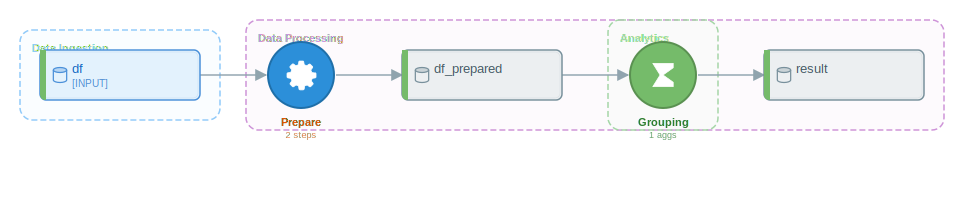

In [59]:
from IPython.display import SVG, display
from py2dataiku.visualizers import DATAIKU_LIGHT, DATAIKU_DARK

# DATAIKU_LIGHT theme (default)
print("=== DATAIKU_LIGHT Theme ===")
light_svg = flow.visualize(format="svg", theme=DATAIKU_LIGHT)
display(SVG(light_svg))

=== DATAIKU_DARK Theme ===


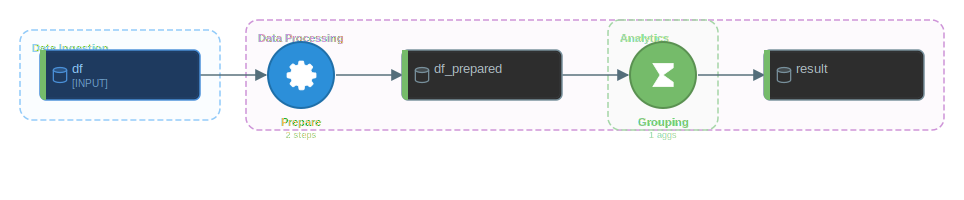

In [60]:
# DATAIKU_DARK theme
print("=== DATAIKU_DARK Theme ===")
dark_svg = flow.visualize(format="svg", theme=DATAIKU_DARK)
display(SVG(dark_svg))

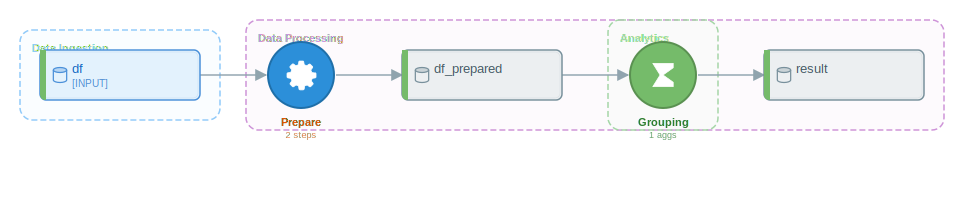

In [61]:
# Jupyter inline display via _repr_svg_() -- just evaluate the flow
flow

## 13. Putting It All Together: End-to-End Expert Workflow

Combine LLM analysis, configuration, zones, and DSS export in a single workflow.

In [62]:
# Step 1: Configure the project
project_cfg = Py2DataikuConfig(
    project_key="E2E_DEMO",
    flow_name="end_to_end_pipeline",
    optimize=True,
    optimization_level=2,
    default_connection="PostgreSQL",
)
print(f"Project: {project_cfg.project_key}")

# Step 2: Convert code (rule-based for this demo)
pipeline_code = """
import pandas as pd
orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')
orders = orders.dropna(subset=['total'])
orders['total'] = orders['total'].round(2)
merged = orders.merge(customers, on='customer_id', how='left')
by_region = merged.groupby('region').agg({'total': 'sum'})
"""
e2e_flow = convert(pipeline_code)
e2e_flow.name = project_cfg.flow_name
print(f"\nFlow: {e2e_flow.name}")
print(f"Recipes: {len(e2e_flow.recipes)}, Datasets: {len(e2e_flow.datasets)}")

Project: E2E_DEMO

Flow: end_to_end_pipeline
Recipes: 4, Datasets: 6


In [63]:
# Step 3: Organize into zones
src_zone = FlowZone(name="Sources", color="#27ae60")
transform_zone = FlowZone(name="Transformations", color="#2980b9")
output_zone = FlowZone(name="Outputs", color="#8e44ad")

for ds in e2e_flow.datasets:
    if ds.dataset_type == DatasetType.INPUT:
        src_zone.add_dataset(ds.name)
    elif ds.dataset_type == DatasetType.OUTPUT:
        output_zone.add_dataset(ds.name)
    else:
        transform_zone.add_dataset(ds.name)

for r in e2e_flow.recipes:
    transform_zone.add_recipe(r.name)

e2e_flow.add_zone(src_zone)
e2e_flow.add_zone(transform_zone)
e2e_flow.add_zone(output_zone)

print("Zones configured:")
for z in e2e_flow.zones:
    print(f"  {z.name}: {len(z.datasets)} datasets, {len(z.recipes)} recipes")

Zones configured:
  Sources: 2 datasets, 0 recipes
  Transformations: 4 datasets, 4 recipes
  Outputs: 0 datasets, 0 recipes


In [64]:
# Step 4: Export to DSS format
dss_config = DSSProjectConfig(
    project_key=project_cfg.project_key,
    project_name="End-to-End Demo Pipeline",
    owner="data_team",
    tags=["demo", "e2e", "py2dataiku"],
)

exporter = DSSExporter(flow=e2e_flow, config=dss_config)
bundle = exporter.get_api_bundle()
print(f"API bundle ready: {bundle['projectKey']}")
print(f"  {len(bundle['datasets'])} datasets")
print(f"  {len(bundle['recipes'])} recipes")
print(f"  Generated: {bundle['metadata']['timestamp'][:19]}")

API bundle ready: E2E_DEMO
  6 datasets
  4 recipes
  Generated: 2026-04-27T22:45:07


In [65]:
# Step 5: Visualize the final flow
print(e2e_flow.get_summary())

Flow: end_to_end_pipeline
Source: unknown
Generated: 2026-04-27T22:45:07.702589

Datasets: 6
  - Input: 2
  - Intermediate: 4
  - Output: 0

Recipes: 4
  - grouping: 1
  - join: 1
  - prepare: 2

Optimization Notes:
  - prepare: 2 recipe(s)
  - join: 1 recipe(s)
  - grouping: 1 recipe(s)
  - Flow contains 2 Prepare recipes


### Visualizing the End-to-End Flow

Multiple visualization formats for the complete pipeline.

In [66]:
# ASCII view of the end-to-end flow
print(e2e_flow.visualize(format='ascii'))

════════════════════════════════════════════════════════════════════════════════
                       DATAIKU FLOW: end_to_end_pipeline  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                                └──────────────┘

                                       

In [67]:
# Mermaid diagram of the end-to-end flow
print(e2e_flow.visualize(format='mermaid'))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(orders)]
        D2[(customers)]
    end
    D1[(orders_prepared)]
    D3[(orders_prepared_prepared)]
    D4[(merged)]
    D5[(by_region)]
    R0{Prepare\n(1 steps)}
    R1{Prepare\n(1 steps)}
    R2{Join\n(LEFT)}
    R3{Grouping\n(1 aggs)}
    D0 --> R0
    R0 --> D1
    D1 --> R1
    R1 --> D3
    D1 --> R2
    D2 --> R2
    R2 --> D4
    D4 --> R3
    R3 --> D5

    style D0 fill:#e1f5fe
    style D2 fill:#e1f5fe
    style R0 fill:#fff3e0
    style R1 fill:#fff3e0
    style R2 fill:#e3f2fd
    style R3 fill:#e8f5e9


In [68]:
# PlantUML diagram of the end-to-end flow
print(e2e_flow.visualize(format='plantuml'))

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles (per-type, DSS-palette)
skinparam card {
  BackgroundColor<<prepare>> #2c8fd9
  BorderColor<<prepare>> #1f6fa9
  FontColor<<prepare>> #ffffff
  BackgroundColor<<sync>> #5d6d7e
  BorderColor<<sync>> #3d4d5e
  FontColor<<sync>> #ffffff
  BackgroundColor<<grouping>> #75bb6a
  BorderColor<<grouping>> #5a9151
  FontColor<<grouping>> #ffffff
  BackgroundColor<<window>> #9b59b6
  BorderColor<<window>> #7d3f97
  FontColor<<window>> #ffffff
  BackgroundColor<<join>> #f29222
  BorderColor<<join>> #c4761a
  FontColor<<j

In [69]:
# Validation check
validation = e2e_flow.validate()
print(f"Valid: {validation['valid']}")
if validation['errors']:
    print(f"Errors: {validation['errors']}")
if validation['warnings']:
    print(f"Warnings: {len(validation['warnings'])}")
if validation['info']:
    print(f"Info: {len(validation['info'])}")

Valid: True


---
## 15. DAG Analysis on Expert Flows

Apply DAG analysis to the end-to-end flow from section 13. The `FlowGraph`
enables topological sorting, cycle detection, path finding, and component discovery.

In [70]:
# DAG analysis of the e2e_flow
dag = e2e_flow.graph
print(f"Flow graph: {dag}")
print(f"Dataset nodes: {len(dag.dataset_nodes)}")
print(f"Recipe nodes: {len(dag.recipe_nodes)}")

# Topological sort -- execution order
print("\nExecution order:")
for i, name in enumerate(dag.topological_sort(), 1):
    node = dag.get_node(name)
    print(f"  {i}. [{node.node_type.value}] {name}")

# Structural analysis
print(f"\nRoot nodes: {dag.get_roots()}")
print(f"Leaf nodes: {dag.get_leaves()}")
print(f"Cycles: {dag.detect_cycles()}")
print(f"Connected components: {len(dag.find_disconnected_subgraphs())}")

Flow graph: FlowGraph(nodes=10, edges=9)
Dataset nodes: 6
Recipe nodes: 4

Execution order:
  1. [dataset] orders
  2. [dataset] customers
  3. [recipe] recipe:prepare_1
  4. [dataset] orders_prepared
  5. [recipe] recipe:prepare_2
  6. [recipe] recipe:join_3
  7. [dataset] orders_prepared_prepared
  8. [dataset] merged
  9. [recipe] recipe:grouping_4
  10. [dataset] by_region

Root nodes: ['orders', 'customers']
Leaf nodes: ['orders_prepared_prepared', 'by_region']
Cycles: []
Connected components: 1


---
## 16. Column Lineage on Complex Pipelines

Trace columns through the e2e pipeline to understand data provenance.

In [71]:
# Trace the 'total' column through the end-to-end flow
lineage = e2e_flow.get_column_lineage("total")
print(f"Column: {lineage.column}")
print(f"Origin dataset: {lineage.origin_dataset}")
print(f"Final dataset: {lineage.final_dataset}")
print(f"Transformations: {lineage.transformations}")

# Lineage as serializable dict
print(f"\nLineage dict: {lineage.to_dict()}")

Column: total
Origin dataset: orders
Final dataset: by_region
Transformations: [{'type': 'join', 'recipe': 'join_3', 'join_type': 'LEFT'}, {'type': 'aggregation', 'recipe': 'grouping_4', 'function': 'SUM', 'source_column': 'total'}]

Lineage dict: {'column': 'total', 'final_dataset': 'by_region', 'origin': {'dataset': 'orders', 'column': 'total'}, 'transformations': [{'type': 'join', 'recipe': 'join_3', 'join_type': 'LEFT'}, {'type': 'aggregation', 'recipe': 'grouping_4', 'function': 'SUM', 'source_column': 'total'}]}


---
## 17. Interactive Visualization

The interactive format provides pan/zoom/search capabilities, ideal for exploring
complex flows.

In [72]:
# Interactive visualization of the e2e_flow
interactive_output = e2e_flow.visualize(format="interactive")
print(f"Interactive output: {len(interactive_output)} characters")

# HTML visualization
html_output = e2e_flow.visualize(format="html")
print(f"HTML output: {len(html_output)} characters")

# Compare all format sizes
print(f"\n{'Format':<15s} {'Size':>10s}")
print("-" * 26)
for fmt in ["ascii", "svg", "html", "mermaid", "plantuml", "interactive"]:
    output = e2e_flow.visualize(format=fmt)
    print(f"{fmt:<15s} {len(output):>8,d} chars")

Interactive output: 37202 characters
HTML output: 44184 characters

Format                Size
--------------------------
ascii              2,946 chars
svg               29,429 chars
html              44,184 chars
mermaid              584 chars
plantuml           6,319 chars
interactive       37,202 chars


---
## 18. Flow Validation with Visual Output

Combine flow validation with visualization to verify and display flow correctness.

In [73]:
# Validate the flow and display results alongside the flow diagram
validation = e2e_flow.validate()
print("=== Flow Validation ===")
print(f"Valid: {validation['valid']}")
if validation['errors']:
    print(f"Errors: {len(validation['errors'])}")
    for e in validation['errors']:
        print(f"  [{e['type']}] {e['message']}")
if validation['warnings']:
    print(f"Warnings: {len(validation['warnings'])}")
    for w in validation['warnings']:
        print(f"  [{w['type']}] {w['message']}")
if validation['info']:
    print(f"Info: {len(validation['info'])}")
    for info in validation['info']:
        print(f"  [{info['type']}] {info['message']}")

# Show the validated flow diagram
print("\n=== Validated Flow (ASCII) ===")
print(e2e_flow.visualize(format="ascii"))

=== Flow Validation ===
Valid: True

=== Validated Flow (ASCII) ===
════════════════════════════════════════════════════════════════════════════════
                       DATAIKU FLOW: end_to_end_pipeline  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 1 steps      │
                     

## Summary

This notebook covered py2dataiku's expert-level features:

| Feature | Key Classes/Functions |
|---|---|
| LLM Providers | `MockProvider`, `AnthropicProvider`, `OpenAIProvider`, `get_provider()` |
| LLM Analysis | `LLMCodeAnalyzer.analyze()` returns `AnalysisResult` |
| Analysis Schema | `AnalysisResult`, `DataStep`, `OperationType` (28 types), `DatasetInfo` |
| Hybrid Conversion | `Py2Dataiku` class with LLM-first, rule-based fallback |
| Configuration | `Py2DataikuConfig`, `load_config()`, TOML/YAML/RC/env support |
| DSS Export | `DSSExporter.export()`, `export_to_dss()`, `DSSProjectConfig` |
| Dataset Connections | `DatasetConnectionType` (13 types), `ColumnSchema` |
| API Output | `flow.to_recipe_configs()` for Dataiku API-compatible configs |
| Flow Zones | `FlowZone` for organizing datasets and recipes |

**Next**: See `05_master.ipynb` for extensibility, scenarios, MLOps, and pipeline examples.

---
## 14. DSS Integration & Deployment

py2dataiku includes an integration module for deploying flows to a Dataiku DSS instance.
Two deployment paths are available:

1. **DSSFlowDeployer** -- Uses the `dataikuapi` Python client to create datasets and recipes via the DSS API
2. **MCP Tool Calls** -- Generates tool call payloads compatible with the [dataiku_factory](https://github.com/hhobin/dataiku_factory) MCP server

Both paths support dry-run mode for previewing deployments without a live connection.

In [74]:
from py2dataiku.integrations import DSSFlowDeployer, DeploymentResult

# Deploy the e2e_flow from section 13 using dry-run mode
deployer = DSSFlowDeployer(
    host="https://dss.example.com",
    api_key="dummy-api-key",
    project_key="E2E_DEMO",
    dry_run=True,
)

result = deployer.deploy(e2e_flow)
print(result)
print(f"\nSuccess: {result.success}")
print(f"Datasets created: {result.datasets_created}")
print(f"Recipes created: {result.recipes_created}")
print(f"Warnings: {result.warnings}")
print(f"Errors: {result.errors}")

DeploymentResult(DRY RUN: 6 datasets, 4 recipes, 0 errors)

Success: True
Datasets created: ['orders', 'customers', 'orders_prepared', 'orders_prepared_prepared', 'merged', 'by_region']
Recipes created: ['prepare_1', 'prepare_2', 'join_3', 'grouping_4']
Warnings: []
Errors: []


In [75]:
from py2dataiku.integrations import generate_mcp_tool_calls

# Generate MCP tool calls for the same flow
tool_calls = generate_mcp_tool_calls(e2e_flow, project_key="E2E_DEMO")

print(f"Generated {len(tool_calls)} MCP tool calls\n")
for i, call in enumerate(tool_calls, 1):
    print(f"Step {i}: {call['tool_name']}")
    args = call["arguments"]
    if call["tool_name"] == "create_dataset":
        print(f"  dataset: {args['dataset_name']} ({args['connection_type']})")
    else:
        print(f"  recipe: {args['recipe_name']} ({args['recipe_type']})")
        print(f"  inputs: {args['inputs']} -> outputs: {args['outputs']}")

Generated 10 MCP tool calls

Step 1: create_dataset
  dataset: orders (Filesystem)
Step 2: create_dataset
  dataset: customers (Filesystem)
Step 3: create_recipe
  recipe: prepare_1 (shaker)
  inputs: ['orders'] -> outputs: ['orders_prepared']
Step 4: create_dataset
  dataset: orders_prepared (Filesystem)
Step 5: create_recipe
  recipe: prepare_2 (shaker)
  inputs: ['orders_prepared'] -> outputs: ['orders_prepared_prepared']
Step 6: create_recipe
  recipe: join_3 (join)
  inputs: ['orders_prepared', 'customers'] -> outputs: ['merged']
Step 7: create_dataset
  dataset: orders_prepared_prepared (Filesystem)
Step 8: create_dataset
  dataset: merged (Filesystem)
Step 9: create_recipe
  recipe: grouping_4 (grouping)
  inputs: ['merged'] -> outputs: ['by_region']
Step 10: create_dataset
  dataset: by_region (Filesystem)


In [76]:
from py2dataiku.integrations import format_mcp_script

# Format the tool calls as a human-readable script
# This output is compatible with the dataiku_factory MCP server
script = format_mcp_script(tool_calls)
print(script)

# MCP Tool Calls for Dataiku DSS
# Total calls: 10

# Step 1: create_dataset
tool: create_dataset
arguments: {
  "project_key": "E2E_DEMO",
  "dataset_name": "orders",
  "connection_type": "Filesystem"
}

# Step 2: create_dataset
tool: create_dataset
arguments: {
  "project_key": "E2E_DEMO",
  "dataset_name": "customers",
  "connection_type": "Filesystem"
}

# Step 3: create_recipe
tool: create_recipe
arguments: {
  "project_key": "E2E_DEMO",
  "recipe_name": "prepare_1",
  "recipe_type": "shaker",
  "inputs": [
    "orders"
  ],
  "outputs": [
    "orders_prepared"
  ],
  "settings": {
    "mode": "NORMAL",
    "steps": [
      {
        "metaType": "PROCESSOR",
        "type": "RemoveRowsOnEmpty",
        "disabled": false,
        "params": {
          "columns": [
            "total"
          ],
          "keep": false
        }
      }
    ]
  }
}

# Step 4: create_dataset
tool: create_dataset
arguments: {
  "project_key": "E2E_DEMO",
  "dataset_name": "orders_prepared",
  "conne

### MCP Integration with dataiku_factory

The MCP tool calls above map directly to the [dataiku_factory](https://github.com/hhobin/dataiku_factory) MCP server,
which exposes tools like `create_dataset`, `create_recipe`, `run_recipe`, and `get_project_flow`.

**Workflow:**
1. Convert Python code to a `DataikuFlow` with `convert()` or `convert_with_llm()`
2. Generate MCP tool calls with `generate_mcp_tool_calls(flow, project_key)`
3. Feed the tool calls to an MCP-aware client (e.g., Claude Desktop with dataiku_factory configured)
4. The MCP server executes each call against the DSS API in topological order

This enables an AI-assisted deployment workflow where an LLM agent can create
entire Dataiku flows from natural language descriptions of data pipelines.